In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
df = pd.read_json('../data/Prepared/car_data.json')

## Data contract (Data Dictionary + Validity Rules)

The dataset in `data/raw/car_data.json` and `data/Prepared/car_data.json` currently uses the same column schema. The table below documents the expected meaning, type, and validation rules for each field.

So this works as checklist when cleaning data.

| Column | Meaning | Type | Valid range/values | Units | Notes |
| --- | --- | --- | --- | --- | --- |
| `url` | listing URL | string | expected to be a valid OLX posting URL | - | should identify a posting, but duplicates are present in the current data |
| `posting_date` | date the listing was posted | date string | usually `DD.MM.YYYY`; some rows use relative text such as `Сегодня` | date | must be normalized before date parsing |
| `region` | seller region in Uzbekistan | category | 13 observed region values including `Tashkent`, `Samarkand`, `Bukhara`, `Karakalpakstan` | - | 1 missing value observed |
| `district` | district or city within a region | category | 230 observed values | - | spelling and naming normalization may be needed |
| `price` | listed sale price | numeric stored as string | positive values; observed range `10,000,000` to `2,008,972,671` | local currency | 5 missing values observed; outliers should be reviewed |
| `currency` | currency code for `price` | category | mostly `UZS` when present | ISO currency code | highly sparse in the current data; many rows are missing |
| `description` | free-text ad description | text | arbitrary seller-written text | - | noisy multilingual text; useful for NLP/features after cleaning |
| `image_url` | main image link for the ad | string | expected `http`/`https` image URL | - | optional; missing values are present |
| `seller_type` | seller classification | category | mostly `private` in observed data | - | many missing values; could later include dealer/business labels |
| `model` | vehicle model name | category/text | 720 observed values | - | may mix trims, generations, and inconsistent naming |
| `body_type` | vehicle body style | category | `Sedan`, `Hatchback`, `Station Wagon`, `SUV`, `Minivan`, `Pickup`, `Coupe`, `Convertible`, `Other` | - | appears complete in the current snapshot |
| `sale_type` | sale terms attached to the listing | multi-label text/category | values such as `Simple Sale`, `Credit`, `Installment`, `Exchange`, `Rent`, often comma-separated combinations | - | multilingual and highly inconsistent; many missing values |
| `year` | vehicle manufacture year | integer stored as string | observed range `1900` to `2025` | year | should be checked against realistic car production years |
| `mileage` | vehicle mileage | integer stored as string | observed range `0` to `10,000,000` | km | missing values and obvious outliers are possible |
| `transmission` | gearbox type | category | `Manual`, `Automatic`, `Other` | - | appears complete in the current snapshot |
| `color` | vehicle color | category | 23 observed color values such as `White`, `Black`, `Gray`, `Blue` | - | synonyms may need consolidation |
| `engine_volume` | engine size | numeric stored as string | observed range `1` to `10000` | unclear/mixed | scale is inconsistent across rows and likely needs normalization before analysis |
| `fuel_type` | fuel system | category | `Gasoline/Gas`, `Gasoline`, `Electric`, `Hybrid`, `Diesel`, `Other` | - | appears complete in the current snapshot |
| `condition` | vehicle condition | category | `Excellent`, `Good`, `Average`, `Needs Repair` | - | ordinal meaning should be preserved if encoded |
| `owners_count` | number of previous owners | ordinal category stored as string | `1`, `2`, `3`, `4+` | owners | missing values are present; `4+` is grouped rather than exact |
| `additional_options` | extra features/options listed in the ad | comma-separated text list | examples include `Customs Cleared`, `Electrical Window Lifters`, parking sensors, etc. | - | multi-valued field; multilingual, sparse, and suitable for splitting into tags |

## Data intake & first checks

### Basic intake checklist:

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47106 entries, 0 to 47105
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 47106 non-null  object 
 1   posting_date        47106 non-null  object 
 2   region              47105 non-null  object 
 3   district            47105 non-null  object 
 4   price               47101 non-null  object 
 5   currency            12571 non-null  object 
 6   description         47106 non-null  object 
 7   image_url           45520 non-null  object 
 8   seller_type         39798 non-null  object 
 9   model               47047 non-null  object 
 10  body_type           47106 non-null  object 
 11  sale_type           18713 non-null  object 
 12  year                47106 non-null  int64  
 13  mileage             43818 non-null  float64
 14  transmission        47106 non-null  object 
 15  color               47106 non-null  object 
 16  engine_vo

### Uniqueness + duplicates

In [85]:
df['url'].nunique()

46106

No dublicate found

### Target integrity check

The target variable (price) represents seller-listed prices, which may include noise due to negotiation strategies and inconsistent reporting.

##  Data quality audit (prove what’s wrong before fixing)

Data quality audit

|Column|% missing |Is missing acceptable?|Why might it be missing?|
|---|---|---|---|
|currency|73%|No|Scraper could not identify USD currency|
|sale_type|60%|Maybe|Sales type not included in description|
|model|1%|No|Model not included in description|
|mileage|7%|Yes(moderate, manageable)|Seller may be hide high usage, older listings may not include it|
|additional_options|34%|Yes|User forgot to include or none exist|

## Cleaning strategy (not just steps-decisions)

In [86]:
df.head(100)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,sale_type,year,mileage,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options
0,https://olx.uz/d/obyavlenie/vaz-2103-gazda-yur...,26.04.2025,Jizzakh,Gallaaral,15000000,UZS,Mator karobka zadnimos qilingan yili 1979,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2103,...,None,1979,NaN,Manual,Red,12,Gasoline/Gas,Good,2,None
1,https://olx.uz/d/obyavlenie/vaz2105zhuguli-god...,26.04.2025,Namangan,Namangan,15000000,UZS,Торг строга укапота машина на ходу полный раб...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2105,...,Simple Sale,1982,72122.0,Manual,Green,1,Gasoline/Gas,Average,1,None
2,https://olx.uz/d/obyavlenie/juguli-21011-sotil...,26.04.2025,Khorezm,Karaul,15000000,UZS,Mashin toxlangan metan 100 lik bo 14 diska b...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: 2101,...,None,1979,0.0,Manual,White,2103,Gasoline/Gas,Good,4+,None
3,https://olx.uz/d/obyavlenie/waxzod-kafolati-bi...,26.04.2025,Jizzakh,Mardzhanbulak,15000000,UZS,31029 96yil matori zor karopka zor magnitafon ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 31029,...,None,1996,560.0,Manual,White,105,Gasoline/Gas,Good,2,None
4,https://olx.uz/d/obyavlenie/mazda-626-starushk...,26.04.2025,Karakalpakstan,Kungrad,15000000,UZS,Прадаётсья на запчасти Мазда 626 старушка 1.6 ...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 626,...,Simple Sale,1986,NaN,Manual,White,16,Gasoline/Gas,Needs Repair,None,"Customs Cleared, Electrical Window Lifters, Па..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,https://olx.uz/d/obyavlenie/jiguli-vaz-lada-21...,18.04.2025,Kashkadarya,Kasan,15000000,UZS,Mator 06 korobka 4tali benzin da 1996yil narxi...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 2106,...,Simple Sale,1996,200000.0,Manual,White,1,Gasoline,Average,1,None
96,https://olx.uz/d/obyavlenie/zaz-40-lik-dakumen...,18.04.2025,Navoi,Navoi,15000000,UZS,запарож 40 лик айби йок балонлар янги мошина д...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: 1140,...,None,1989,444444.0,Manual,White,41,Gasoline,Good,1,None
97,https://olx.uz/d/obyavlenie/prodam-zhiguli-210...,18.04.2025,Tashkent,Tashmore,15000000,UZS,Цвет-синий. В хорошем состоянии. Топливо-бензи...,None,private,: 2106,...,Simple Sale,1990,37000.0,Manual,Blue,11,Gasoline,Good,2,Security System
98,https://olx.uz/d/obyavlenie/ford-scorpio-1-pok...,18.04.2025,Tashkent,TashkentYashnabadskiy rayon,15000000,UZS,"Техническое состояние хорошее, \nВ этом году б...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Scorpio,...,None,1986,NaN,Manual,Red,2,Gasoline,Good,2,None


### Standardization rules (categorical)

#### Starting off with `model` column

In [87]:
df['model'].unique()

array([': 2103', ': 2105', ': 2101', ': 31029', ': 626', ': 2109',
       ': 2108', ': 412', ': 2107', ': 21', ': 2106', ': 1102 Таврия',
       ': 2111', ': 2401', ': 2125 Комби', ': Tico', ': Прочее',
       ': Skyline GT-R', ': 2140', ': 469', ': 69', ': 24', ': Другая',
       ': 21109', ': 21099', ': Courier', ': 100', ': 1140', ': Scorpio',
       ': 21011', ': 21111', ': 66', ': Korando', ': 2102', ': Omega',
       ': 31', ': 3110', ': GE3', ': Ascona', ': 2121 Нива', ': 407',
       ': Largus', ': 2141', ': 21093', ': Sierra', ': 2715', ': 2110',
       ': 80', ': Matiz', ': 1117 Kalina универсал', ': 2410', ': 21013',
       ': 21124', ': Cabriolet', ': ASLK 2137', ': 3102', ': 2104',
       ': Simbir', ': Patriot', ': 21106', ': Golf', ': 968M', ': Escort',
       ': 968', ': Taunus', ': 2402', ': Fiesta', ': 21060', ': Uno',
       ': S3', ': 126', ': Sens', ': 2206', ': Jetta', ': 21051',
       ': Espero', ': 21061', ': 1118 Kalina седан', ': 401', ': Arcadia',
       ': 

The original model column contained inconsistent representations, including numeric codes, partial names, and mixed-language values. A mapping dictionary was created to standardize these into unified car names and extract brand information, improving feature quality for modeling.

In [88]:
model_to_name = {

    # LADA (VAZ)
    "2101": "Lada 2101",
    "2102": "Lada 2102",
    "2103": "Lada 2103",
    "2104": "Lada 2104",
    "2105": "Lada 2105",
    "2106": "Lada 2106",
    "2107": "Lada 2107",
    "2108": "Lada Samara 2108",
    "2109": "Lada Samara 2109",
    "21099": "Lada Samara 21099",
    "21011": "Lada 21011",
    "21013": "Lada 21013",
    "21061": "Lada 21061",
    "21063": "Lada 21063",
    "21071": "Lada 21071",
    "21073": "Lada 21073",
    "21083": "Lada Samara 21083",
    "21093": "Lada Samara 21093",
    "2121 Нива": "Lada Niva",
    "21214 Niva": "Lada Niva 21214",
    "4x4": "Lada Niva 4x4",
    "Kalina": "Lada Kalina",
    "1117 Kalina универсал": "Lada Kalina Wagon",
    "1118 Kalina седан": "Lada Kalina Sedan",
    "1119 Kalina хэтчбэк": "Lada Kalina Hatchback",
    "2110": "Lada 2110",
    "2111": "Lada 2111",
    "2112": "Lada 2112",
    "2113": "Lada 2113",
    "2114": "Lada 2114",
    "2115": "Lada 2115",
    "21124": "Lada 21124",
    "21106": "Lada 21106",

    # GAZ (Volga / UAZ style)
    "24": "GAZ 24 Volga",
    "2410": "GAZ 2410 Volga",
    "2401": "GAZ 2401",
    "2402": "GAZ 2402",
    "3102": "GAZ 3102 Volga",
    "31029": "GAZ 31029",
    "3110": "GAZ 3110",
    "3102i": "GAZ 3102i",

    #  MOSKVICH / IZH
    "412": "Moskvich 412",
    "412 Э": "Moskvich 412",
    "2140": "Moskvich 2140",
    "2141": "Moskvich 2141",
    "21412": "Moskvich 21412",
    "ASLK 2140": "Moskvich 2140",
    "ASLK 2137": "Moskvich 2137",
    "2137 Kombi": "Moskvich 2137 Kombi",
    "2136 Kombi": "Moskvich 2136 Kombi",

    # 🟢 DAEWOO (very important in Uzbekistan)
    "Matiz": "Daewoo Matiz",
    "Nexia": "Daewoo Nexia",
    "Damas": "Daewoo Damas",
    "Tico": "Daewoo Tico",
    "Espero": "Daewoo Espero",

    #  CHEVROLET (UzAuto)
    "Lacetti": "Chevrolet Lacetti",
    "Gentra": "Chevrolet Gentra",
    "Cobalt": "Chevrolet Cobalt",
    "Spark": "Chevrolet Spark",
    "Malibu": "Chevrolet Malibu",
    "Tracker": "Chevrolet Tracker",
    "Onix": "Chevrolet Onix",
    "Captiva": "Chevrolet Captiva",

    # HYUNDAI
    "Sonata": "Hyundai Sonata",
    "Accent": "Hyundai Accent",
    "Elantra": "Hyundai Elantra",

    # KIA
    "Rio": "Kia Rio",
    "Sportage": "Kia Sportage",

    # VOLKSWAGEN
    "Passat": "Volkswagen Passat",
    "Golf": "Volkswagen Golf",
    "Golf III": "Volkswagen Golf III",
    "Golf VI": "Volkswagen Golf VI",
    "Jetta": "Volkswagen Jetta",
    "Transporter": "Volkswagen Transporter",
    "Scirocco": "Volkswagen Scirocco",

    #  NISSAN
    "Maxima": "Nissan Maxima",
    "Skyline GT-R": "Nissan Skyline GT-R",
    "Bluebird": "Nissan Bluebird",
    "R Nessa": "Nissan R'nessa",
    "Pathfinder": "Nissan Pathfinder",

    #  TOYOTA
    "Corolla": "Toyota Corolla",
    "Camry": "Toyota Camry",
    "Hiace": "Toyota Hiace",
    "Lite Ace": "Toyota LiteAce",

    #  FORD
    "Escort": "Ford Escort",
    "Fiesta": "Ford Fiesta",
    "Scorpio": "Ford Scorpio",

    # MERCEDES-BENZ
    "190": "Mercedes-Benz 190",
    "C 250": "Mercedes-Benz C250",
    "SL 320": "Mercedes-Benz SL320",

    # BMW
    "520": "BMW 520",

    # HONDA
    "Civic": "Honda Civic",

    # OPEL
    "Vectra": "Opel Vectra",
    "Omega": "Opel Omega",
    "Ascona": "Opel Ascona",
    "Rekord": "Opel Rekord",

    # FIAT
    "Uno": "Fiat Uno",
    "Croma": "Fiat Croma",

    # UAZ
    "469": "UAZ 469",
    "469Б": "UAZ 469",
    "3151": "UAZ 3151",
    "3159": "UAZ 3159",
    "3303": "UAZ 3303",
    "2206": "UAZ 2206",

    # ZAZ
    "968": "ZAZ 968",
    "968M": "ZAZ 968M",
    "1102 Таврия": "ZAZ Tavria",
    "1102": "ZAZ Tavria",
    "1111 Ока": "ZAZ Oka",

    # garbage / unknown
    "Прочее": None,
    "Другая": None,
}

In [89]:
brand_map = {

    # Daewoo
    "Tico": "Daewoo",
    "Matiz": "Daewoo",
    "Nexia": "Daewoo",
    "Damas": "Daewoo",
    "Espero": "Daewoo",

    # Chevrolet (UzAuto)
    "Lacetti": "Chevrolet",
    "Spark": "Chevrolet",
    "Cobalt": "Chevrolet",
    "Malibu": "Chevrolet",
    "Tracker": "Chevrolet",
    "Onix": "Chevrolet",
    "Gentra": "Chevrolet",
    "Captiva": "Chevrolet",

    # Volkswagen
    "Passat": "Volkswagen",
    "Golf": "Volkswagen",
    "Golf III": "Volkswagen",
    "Golf VI": "Volkswagen",
    "Jetta": "Volkswagen",
    "Transporter": "Volkswagen",
    "Scirocco": "Volkswagen",

    # Nissan
    "Maxima": "Nissan",
    "Skyline GT-R": "Nissan",
    "Bluebird": "Nissan",
    "R Nessa": "Nissan",
    "Pathfinder": "Nissan",

    # Hyundai
    "Sonata": "Hyundai",
    "Accent": "Hyundai",
    "Elantra": "Hyundai",

    # Kia
    "Rio": "Kia",
    "Sportage": "Kia",

    # Toyota
    "Corolla": "Toyota",
    "Camry": "Toyota",
    "Hiace": "Toyota",
    "Lite Ace": "Toyota",

    # Ford
    "Escort": "Ford",
    "Fiesta": "Ford",
    "Scorpio": "Ford",

    # Mercedes-Benz
    "190": "Mercedes-Benz",
    "C 250": "Mercedes-Benz",
    "SL 320": "Mercedes-Benz",

    # BMW
    "520": "BMW",

    # Opel
    "Vectra": "Opel",
    "Omega": "Opel",
    "Ascona": "Opel",
    "Rekord": "Opel",

    # Fiat
    "Uno": "Fiat",
    "Croma": "Fiat",

    # UAZ
    "469": "UAZ",
    "469Б": "UAZ",
    "3151": "UAZ",
    "3159": "UAZ",
    "3303": "UAZ",
    "2206": "UAZ",

    # ZAZ
    "968": "ZAZ",
    "968M": "ZAZ",
    "1102 Таврия": "ZAZ",
    "1102": "ZAZ",
    "1111 Ока": "ZAZ",

    # Moskvich / IZH
    "412": "Moskvich",
    "412 Э": "Moskvich",
    "2140": "Moskvich",
    "2141": "Moskvich",
    "21412": "Moskvich",
    "ASLK 2140": "Moskvich",
    "ASLK 2137": "Moskvich",
    "2137 Kombi": "Moskvich",
    "2136 Kombi": "Moskvich",

    # GAZ
    "24": "GAZ",
    "2410": "GAZ",
    "2401": "GAZ",
    "2402": "GAZ",
    "3102": "GAZ",
    "31029": "GAZ",
    "3110": "GAZ",
    "3102i": "GAZ",

    # Lada (VAZ)
    "2101": "Lada",
    "2102": "Lada",
    "2103": "Lada",
    "2104": "Lada",
    "2105": "Lada",
    "2106": "Lada",
    "2107": "Lada",
    "2108": "Lada",
    "2109": "Lada",
    "21011": "Lada",
    "21013": "Lada",
    "21051": "Lada",
    "21061": "Lada",
    "21071": "Lada",
    "21073": "Lada",
    "21083": "Lada",
    "21093": "Lada",
    "21099": "Lada",

    "2110": "Lada",
    "2111": "Lada",
    "2113": "Lada",
    "21106": "Lada",
    "21124": "Lada",

    "2121 Нива": "Lada",
    "21214 Niva": "Lada",
    "4x4": "Lada",

    "1117 Kalina универсал": "Lada",
    "1118 Kalina седан": "Lada",
    "1119 Kalina хэтчбэк": "Lada",

    # fallback garbage
    "Прочее": None,
    "Другая": None,
}

In [90]:
df['model_clean'] = df['model'].str.replace(":","", regex=False).str.strip()
df['car_name'] = df['model_clean'].map(model_to_name)

In [91]:
def assign_brand(model):
    if model.isdigit():
        num = int(model)

        if 2100 <= num <= 2199:
            return 'Lada'
        
        elif num in [24, 31, 3102, 31029, 3110]:
            return 'GAZ'
        
        elif num in [80, 100, 200, 50]:
            return 'Audi'
        
        elif num in [2140, 2141, 412]:
            return 'Moskvich'
    return None
def get_brand(model):
    model = str(model)

    brand = assign_brand(model)
    if brand:
        return brand
    
    for key in brand_map:
        if key.lower()in model.lower():
            return brand_map[key]
    return "Other"

In [92]:
df["brand"] = df["model_clean"].apply(get_brand)
df["car_name"] = df["car_name"].fillna(df["model_clean"])

- `groupby()` is used to find model names to find common brands based on model names
- Not all data points are equally important — high-frequency categories contribute most to model performance.

In [93]:
df.groupby('model_clean')['model_clean'].count().sort_values(ascending=False)

model_clean
Nexia      6536
Lacetti    5154
Matiz      4363
Damas      3934
Cobalt     3918
           ... 
Lavita        1
Laurel        1
21312         1
2138          1
410           1
Name: model_clean, Length: 720, dtype: int64

<Axes: ylabel='brand'>

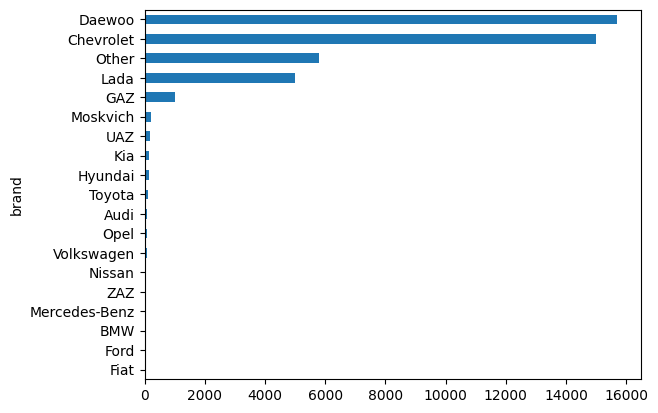

In [99]:
df.groupby('brand')['brand'].count().sort_values().plot(kind='barh')

In [97]:
df.tail(100)

,url,posting_date,region,district,price,currency,description,image_url,seller_type,model,...,transmission,color,engine_volume,fuel_type,condition,owners_count,additional_options,model_clean,car_name,brand
47006,https://olx.uz/d/obyavlenie/chery-7-pro-premiu...,10.05.2025,Surkhandarya,Sariasiya,23500..,None,Moshin yangi xolatda bir tomchi keraska xam yo...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Прочее,...,Automatic,White,16,Gasoline/Gas,Excellent,1,Customs Cleared,Прочее,Прочее,None
47007,https://olx.uz/d/obyavlenie/swm-g05-pro-propan...,09.05.2025,Navoi,Navoi,23500..,None,Машина хорошая не битая очень красивая фарик х...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Прочее,...,Automatic,Black,10,Gasoline/Gas,Excellent,1,"Security System, Electrical Window Lifters, Па...",Прочее,Прочее,None
47008,https://olx.uz/d/obyavlenie/aktsiya-elektro-mo...,09.05.2025,Bukhara,Buhara,23500..,None,Исталган ранг ярашадиган электромобил қайси?!\...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,None,: Song Plus EV Champion,...,Automatic,White,220,Electric,Excellent,1,"Customs Cleared, Electrical Mirrors, Electrica...",Song Plus EV Champion,Song Plus EV Champion,Other
47009,https://olx.uz/d/obyavlenie/leapmotor-c10-ev-5...,13.05.2025,Tashkent,TashkentAlmazarskiy rayon,23200..,None,Leapmotor C10 EV 530km \nОфициальная гарантия\...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: C10 EV,...,Automatic,Black,1,Electric,Excellent,None,"Customs Cleared, Electrical Mirrors, Electrica...",C10 EV,C10 EV,Other
47010,https://olx.uz/d/obyavlenie/kaptiva-5-primer-f...,14.05.2025,Kashkadarya,Kitab,23000..,None,"Каптива без пробег мишлен балон ,⁷ тонировка ,...",https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Captiva,...,Automatic,Black,15,Gasoline,Excellent,1,"Парктроник, Electrical Mirrors, Customs Cleare...",Captiva,Chevrolet Captiva,Chevrolet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47101,https://olx.uz/d/obyavlenie/kia-bongo-2023-sot...,15.04.2025,Bukhara,Buhara,300000000,UZS,Propan òrnatilgan\nFurgon qilingan\nKandisione...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Другая,...,Manual,White,80,Gasoline/Gas,Excellent,4+,"Парктроник, Electrical Mirrors, Customs Cleare...",Другая,Другая,None
47102,https://olx.uz/d/obyavlenie/inavate-elektro-mo...,13.05.2025,Surkhandarya,Termez,300000000,UZS,Mashina ideal oq rangi qiziriq tumanida inavat...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Другая,...,Automatic,White,3,Electric,Excellent,1,None,Другая,Другая,None
47103,https://olx.uz/d/obyavlenie/malibu-2-turbo-pri...,13.05.2025,Khorezm,Karaul,300000000,UZS,Йили 2019 пробег 81800 янги краска йук нархи 2...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Malibu,...,Automatic,Black,2,Gasoline/Gas,Excellent,2,Air Conditioner,Malibu,Chevrolet Malibu,Chevrolet
47104,https://olx.uz/d/obyavlenie/treaker-2-premier-...,10.05.2025,Navoi,Navoi,300000000,UZS,Mashina. Yangi. Salondan. Chiqanganiga e...,https://frankfurt.apollo.olxcdn.com:443/v1/fil...,private,: Tracker,...,Automatic,Black,12,Gasoline,Excellent,4+,"Air Conditioner, Electrical Mirrors, Парктрони...",Tracker,Chevrolet Tracker,Chevrolet
